### Astrostatistics lecture 15

In [98]:
import urllib.request
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import stats
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.cluster import MeanShift
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")
df_stars = pd.read_csv("stars.csv")

In [99]:
df_stars        #our data set

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


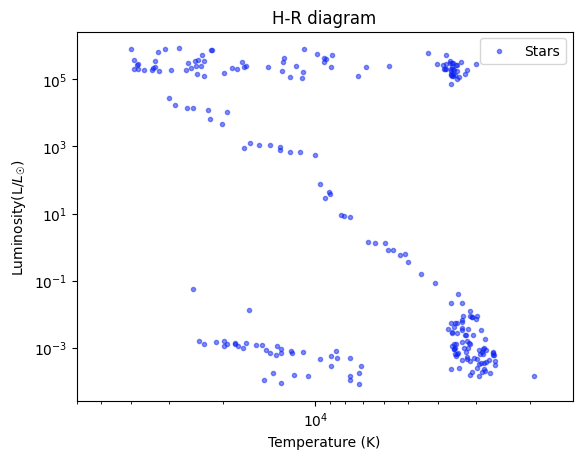

In [100]:
#need to extract the features from the data set, so we convert them in arrays

temperature = np.array(df_stars["Temperature (K)"])
luminosity = np.array(df_stars["Luminosity(L/Lo)"])
radius = np.array(df_stars["Radius(R/Ro)"])
absolute_magnitude = np.array(df_stars["Absolute magnitude(Mv)"])
classification = np.array(df_stars["Star type"])

plt.scatter(temperature, luminosity, color="#0B22F1", alpha=0.5, label='Stars', marker='.')
plt.title('H-R diagram')
plt.xscale('log')
plt.yscale('log')
plt.xlim(max(temperature)*1.5, min(temperature)*0.75)
plt.xlabel("Temperature (K)")
plt.ylabel(f"Luminosity(L/$L_☉$)")
plt.legend()
plt.show()

The explained variance is: 0.9999942118846565


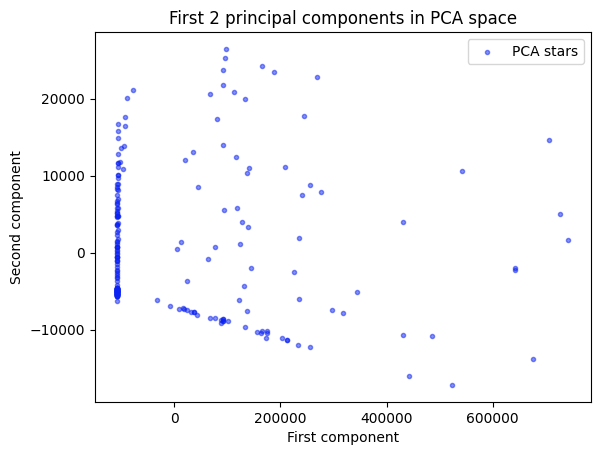

In [101]:
#if we don't rescale the data 
data = np.array([temperature, luminosity, radius, absolute_magnitude]).T #.T used to have the correct (n_values, n_features) shape 

pca = PCA(n_components=2) # 2 components
data_pca = pca.fit_transform(data)

evals = pca.explained_variance_ratio_ 
print(f"The explained variance is: {np.sum(evals)}")

plt.scatter(data_pca[:, 0], data_pca[:, 1], color="#0B22F1", alpha=0.5, label='PCA stars', marker='.')
plt.xlabel("First component")
plt.ylabel("Second component")
plt.title("First 2 principal components in PCA space")
plt.legend()
plt.show()

The explained variance is: 0.8385817508043482


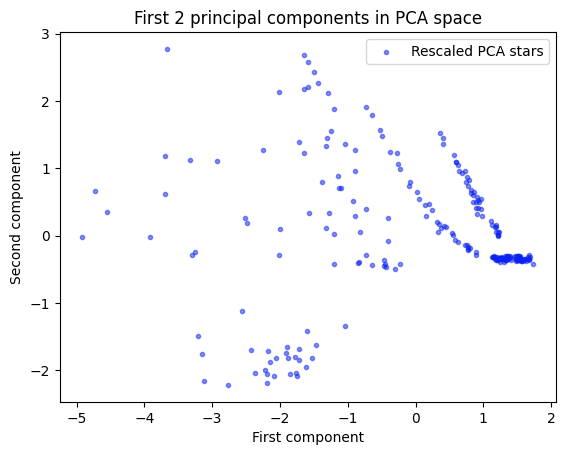

In [106]:
#Now we first standardize the data
data_raw = np.array([temperature, luminosity, radius, absolute_magnitude]).T
scaler = StandardScaler()
data = scaler.fit_transform(data_raw)

pca = PCA(n_components=2) # 2 components

#now project back into PCA space
data_pca = pca.fit_transform(data)

evals = pca.explained_variance_ratio_ 
print(f"The explained variance is: {np.sum(evals)}")



plt.scatter(data_pca[:, 0], data_pca[:, 1], color="#0B22F1", alpha=0.5, label='Rescaled PCA stars', marker='.')
plt.xlabel("First component")
plt.ylabel("Second component")
plt.title("First 2 principal components in PCA space")
plt.legend()
plt.show()


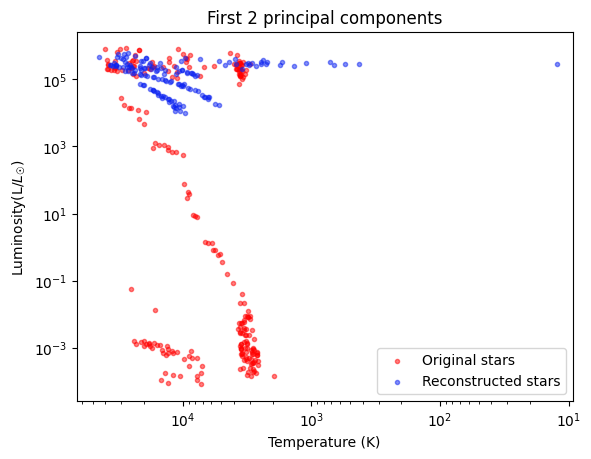

In [107]:
#back into the original space we should get the original data (sort of)
data_back = pca.inverse_transform(data_pca)
data_rec = scaler.inverse_transform(data_back)

plt.scatter(data_raw[:, 0], data_raw[:, 1], label="Original stars", alpha=0.5, color='red', marker='.')
plt.scatter(data_rec[:, 0], data_rec[:, 1], label='Reconstructed stars', color="#0B22F1", alpha=0.5, marker='.')
plt.xlabel("Temperature (K)")
plt.ylabel(f"Luminosity(L/$L_☉$)")
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(max(data_rec[:, 0])*1.5, min(data_rec[:, 0])*0.75)
plt.title("First 2 principal components")
plt.show()